<a href="https://www.kaggle.com/code/lalit7881/predicting-stellar-classes-97?scriptVersionId=329767165" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import balanced_accuracy_score, confusion_matrix,classification_report
import math
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


## Loading dataset

In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
test_df= pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')

In [3]:
print(f"Train dataset : {train_df.shape}")

Train dataset : (577347, 12)


In [4]:
print(f"Test dataset : {test_df.shape}")

Test dataset : (247435, 11)


In [5]:
train_df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [6]:
display(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


None

In [7]:
display(train_df.describe())

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


## 
Null checking

In [8]:
print('\nMissing Values')
print("\n===============================")
print(train_df.isnull().sum())


Missing Values

id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


## Univariate Analysis

In [9]:
cat_cols = train_df.select_dtypes(include=['object']).columns.drop(['class']).tolist()

num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop(['id']).tolist()

target_col = 'class'

In [10]:
print(f"Categorical Features: {cat_cols}")

Categorical Features: ['spectral_type', 'galaxy_population']


In [11]:
print(f"\nNumerical Features: {num_cols}")


Numerical Features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


In [12]:
print(f"\nTarget Feature: {target_col}")


Target Feature: class


In [13]:
train_df['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [14]:
sns.set_style("whitegrid")

colors = ['#4C72B0', '#55A868', '#C44E52']

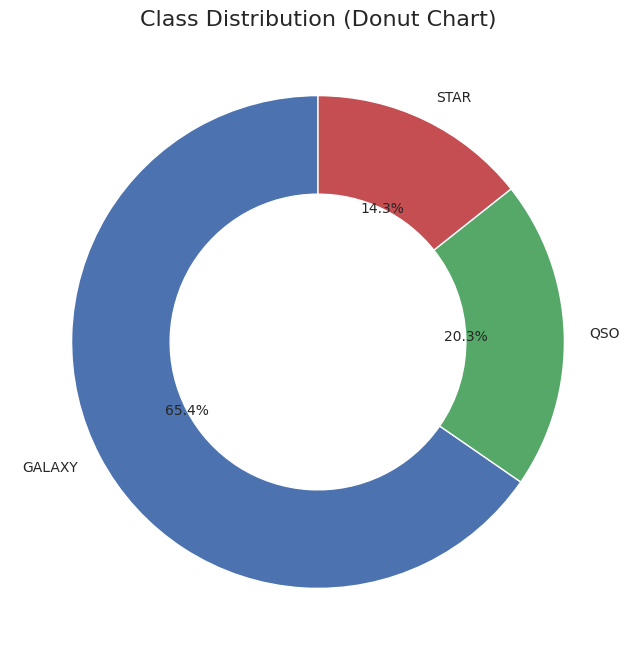

In [15]:
plt.figure(figsize=(8,8))

class_counts = train_df['class'].value_counts()

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4}
)

plt.title('Class Distribution (Donut Chart)', fontsize=16)
plt.show()

## Distribution of Numerical Features¶

In [16]:
train_df[num_cols].describe()

,alpha,delta,u,g,r,i,z,redshift
count,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


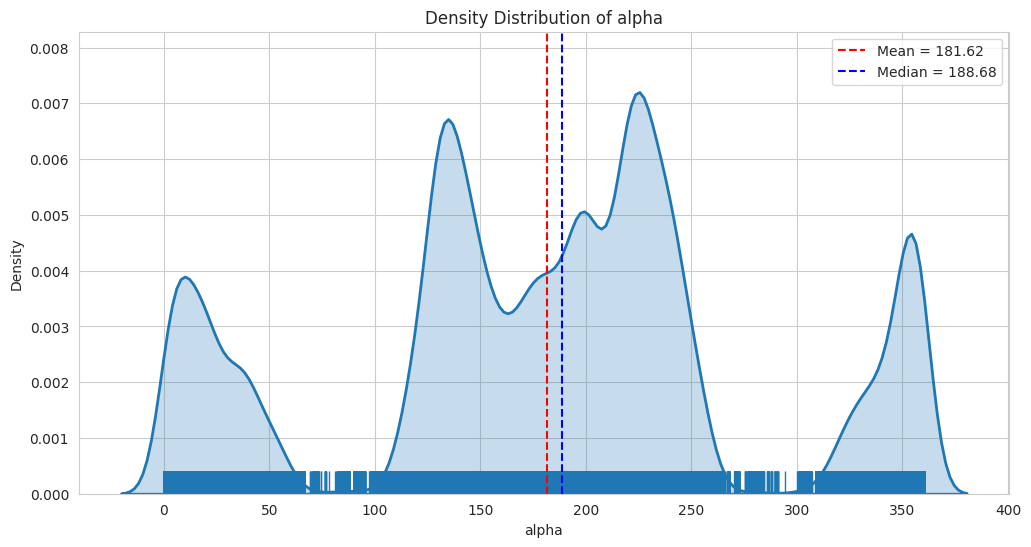

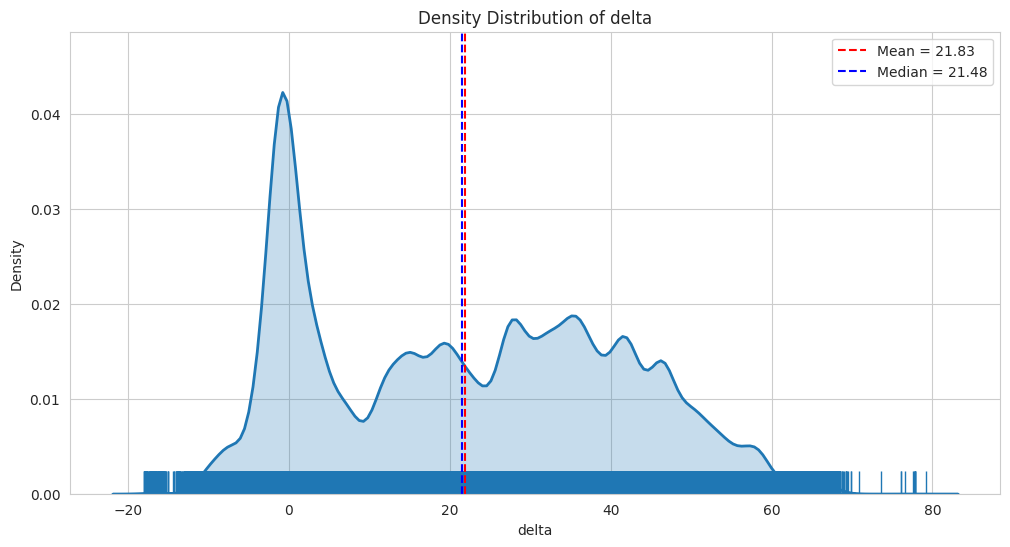

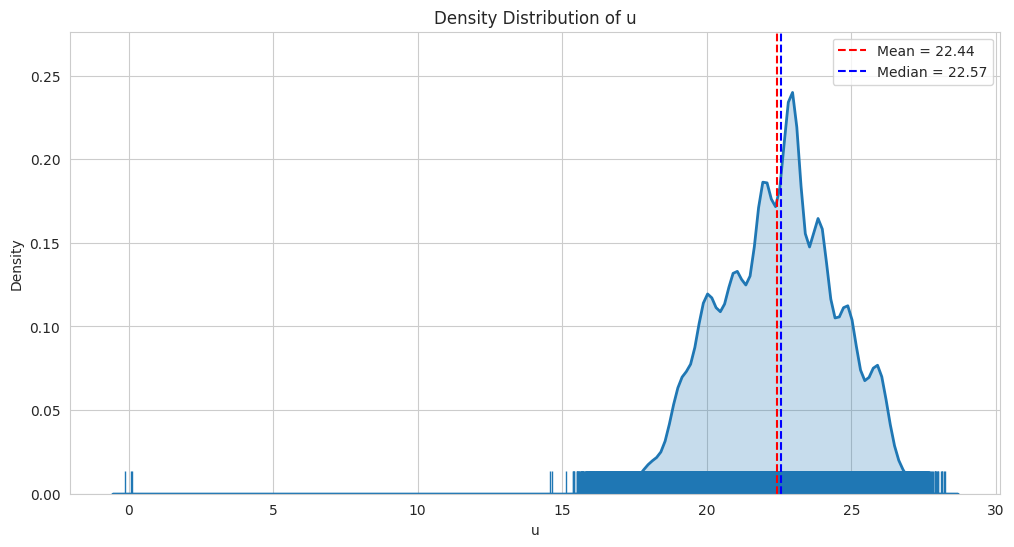

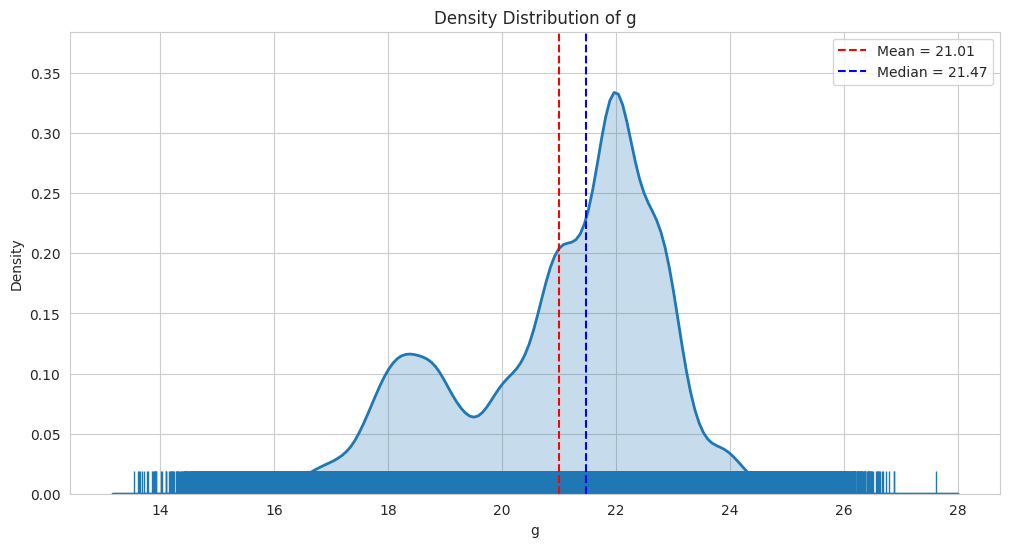

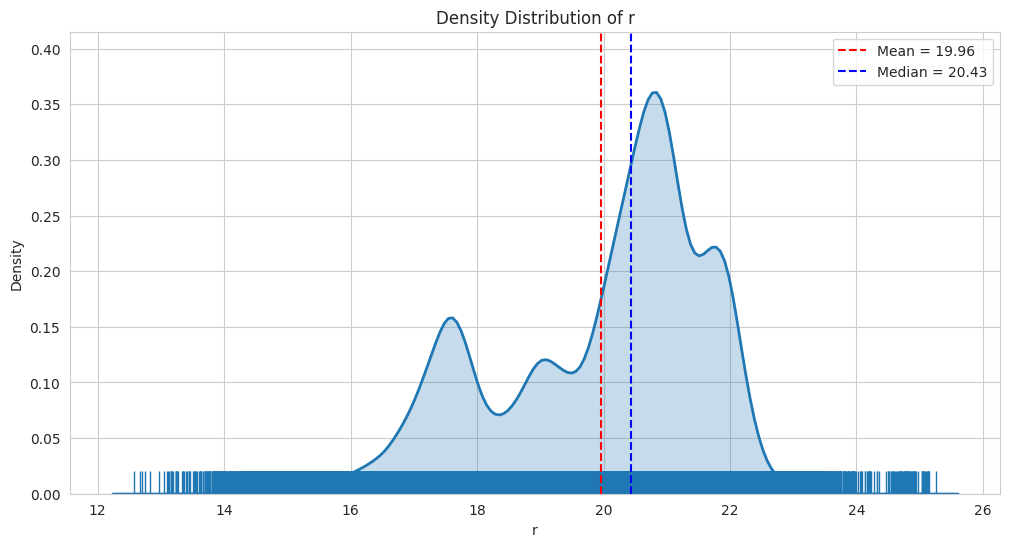

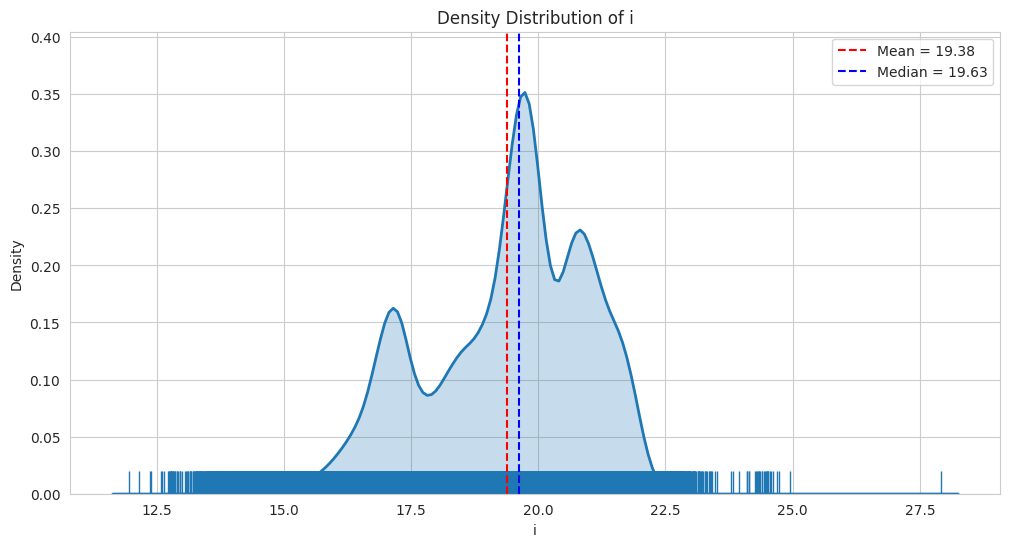

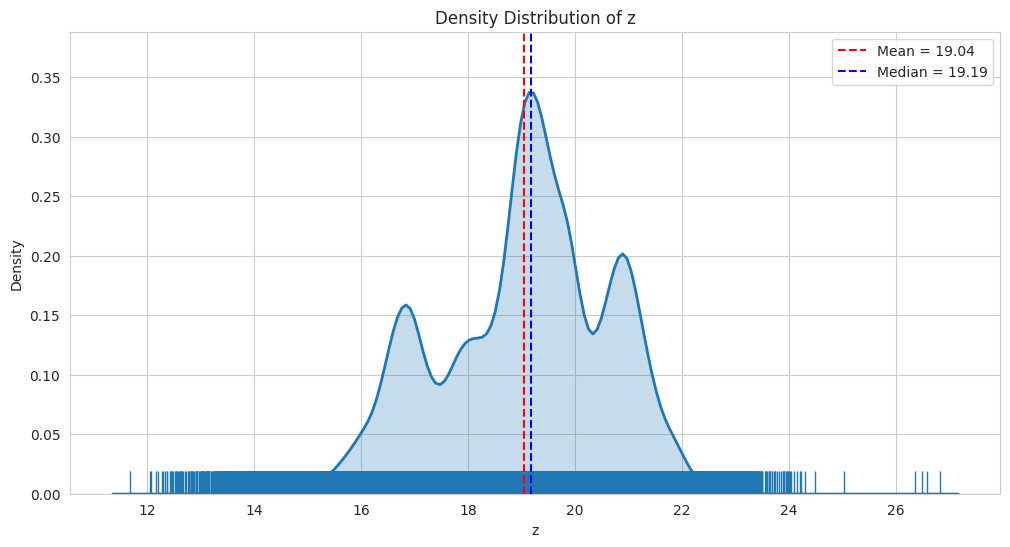

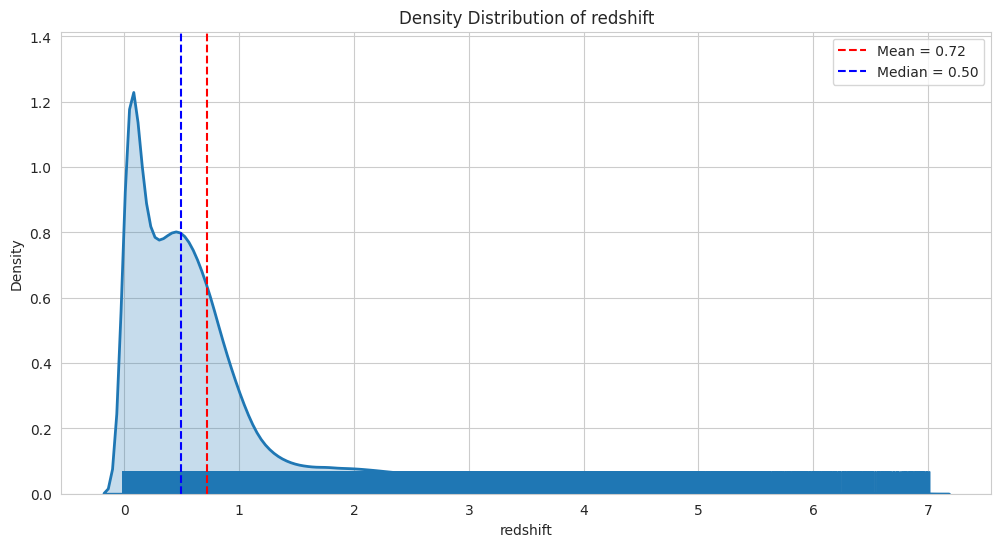

In [17]:
for col in num_cols:

    plt.figure(figsize=(12,6))

    sns.kdeplot(
        data=train_df,
        x=col,
        fill=True,
        linewidth=2
    )

    sns.rugplot(
        data=train_df,
        x=col,
        height=0.05
    )

    mean_val = train_df[col].mean()
    median_val = train_df[col].median()

    plt.axvline(mean_val,
                color='red',
                linestyle='--',
                label=f'Mean = {mean_val:.2f}')

    plt.axvline(median_val,
                color='blue',
                linestyle='--',
                label=f'Median = {median_val:.2f}')

    plt.title(f'Density Distribution of {col}')
    plt.legend()
    plt.show()

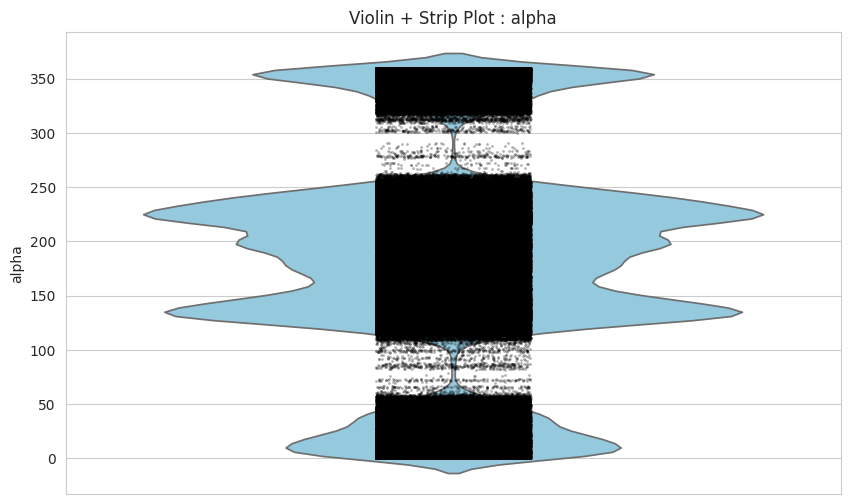

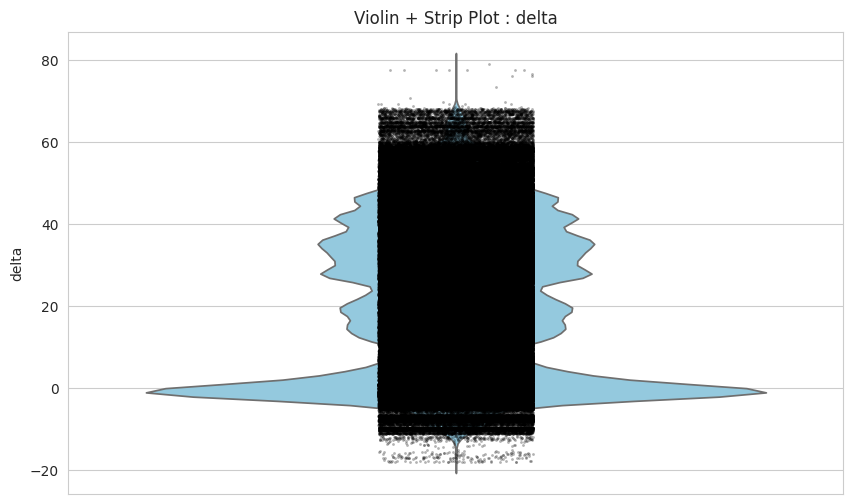

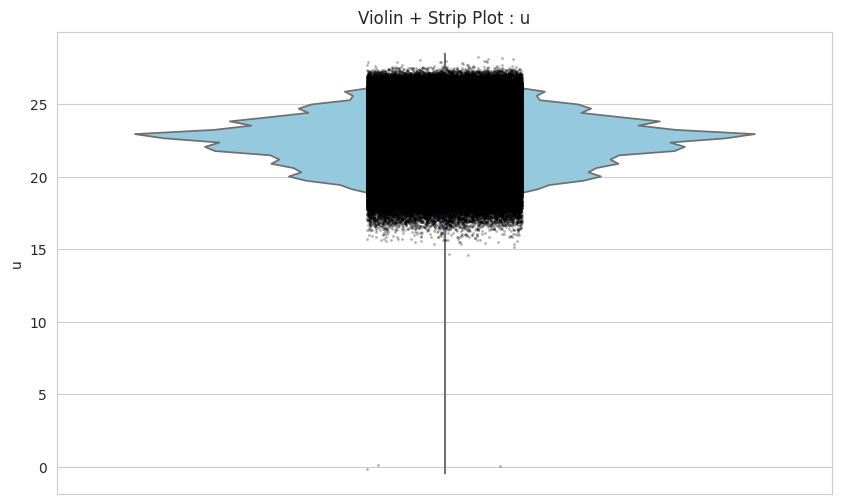

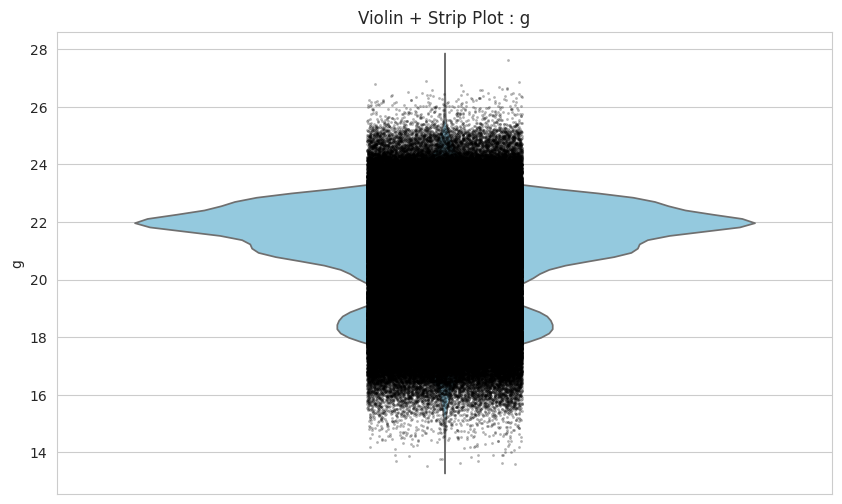

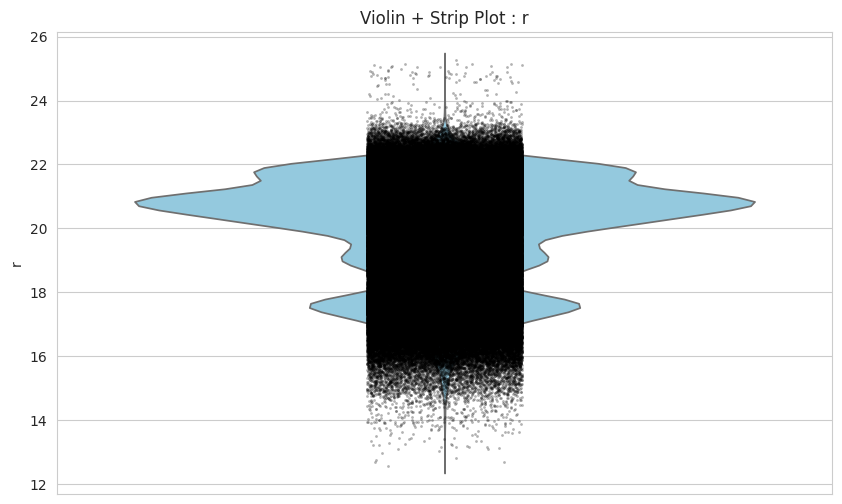

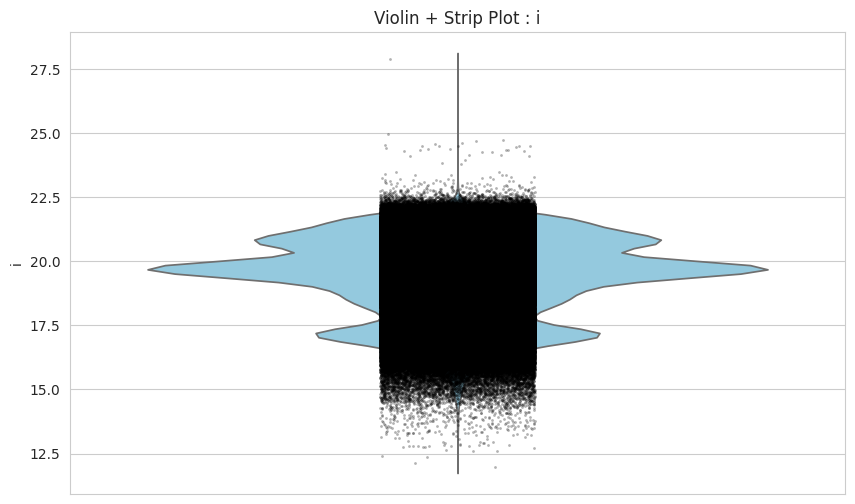

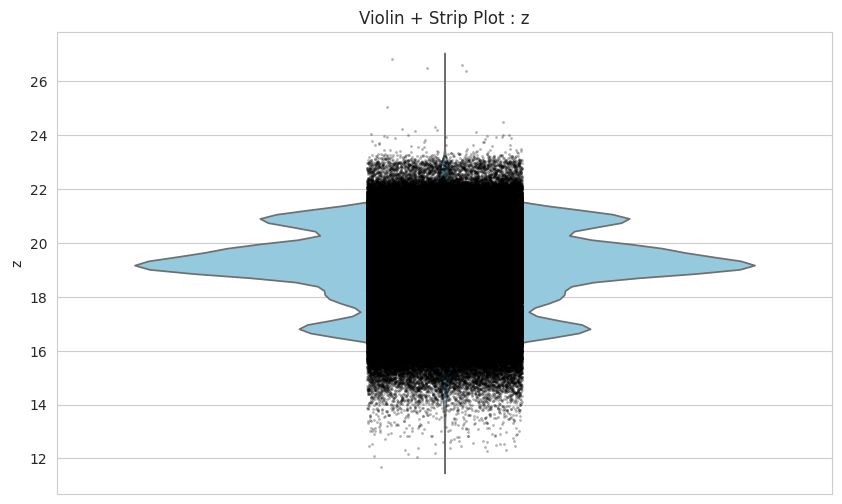

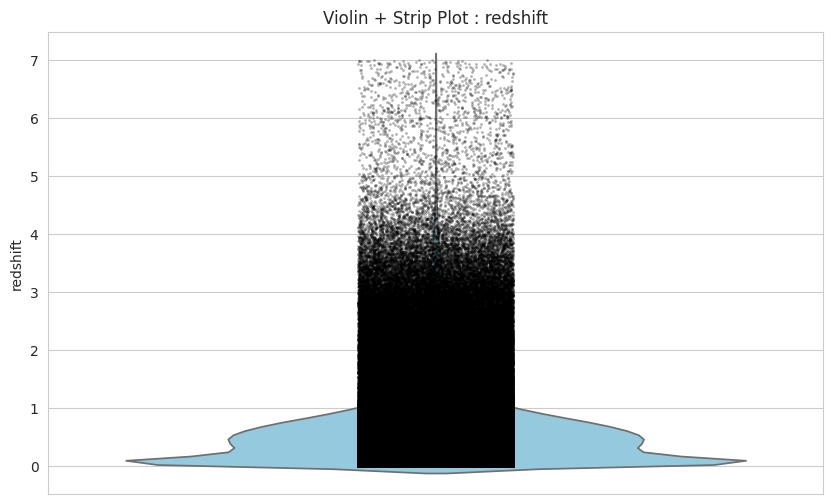

In [18]:
for col in num_cols:

    plt.figure(figsize=(10,6))

    sns.violinplot(
        y=train_df[col],
        inner=None,
        color='skyblue'
    )

    sns.stripplot(
        y=train_df[col],
        color='black',
        alpha=0.3,
        size=2
    )

    plt.title(f'Violin + Strip Plot : {col}')
    plt.show()

In [19]:
train_df[cat_cols].describe()

,spectral_type,galaxy_population
count,577347,577347
unique,4,2
top,M,Red_Sequence
freq,303323,319565


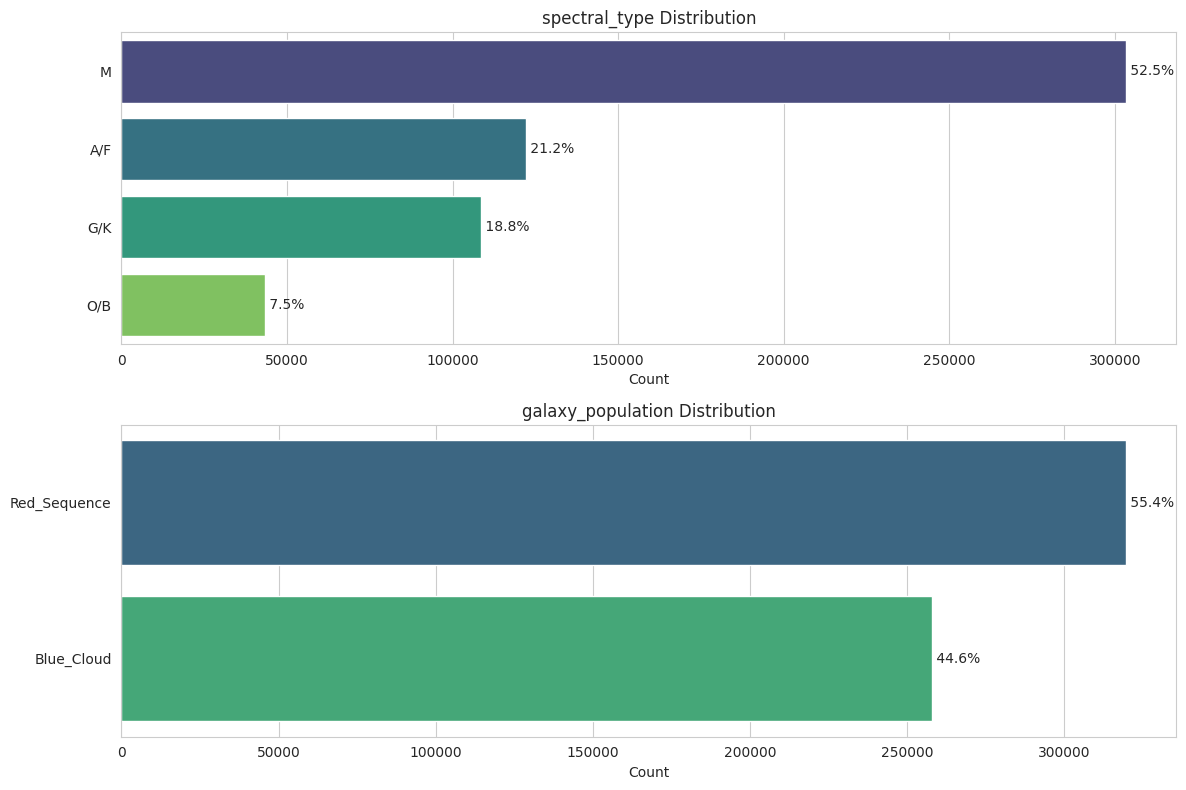

In [20]:
n_rows = len(cat_cols)

fig, axes = plt.subplots(
    n_rows, 1,
    figsize=(12, n_rows * 4)
)

if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):

    counts = train_df[col].value_counts()

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        hue=counts.index,
        palette='viridis',
        legend=False,
        ax=axes[i]
    )

    total = counts.sum()

    for j, v in enumerate(counts.values):
        ax.text(
            v,
            j,
            f' {100*v/total:.1f}%',
            va='center'
        )

    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Multivariate Analysis

## categorical features

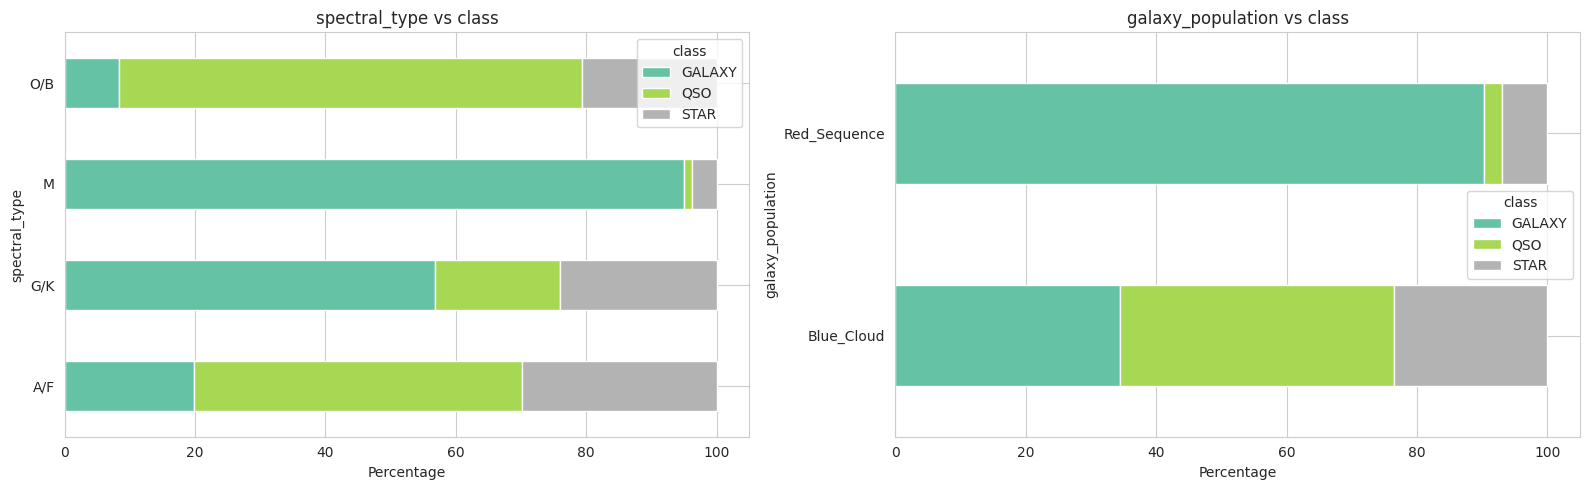

In [21]:
n_cols = 2
n_rows = math.ceil(len(cat_cols)/n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, n_rows*5)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    temp = pd.crosstab(
        train_df[col],
        train_df[target_col],
        normalize='index'
    ) * 100

    temp.plot(
        kind='barh',
        stacked=True,
        colormap='Set2',
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs {target_col}')
    axes[i].set_xlabel('Percentage')

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Linear Feature Correlation Matrix¶

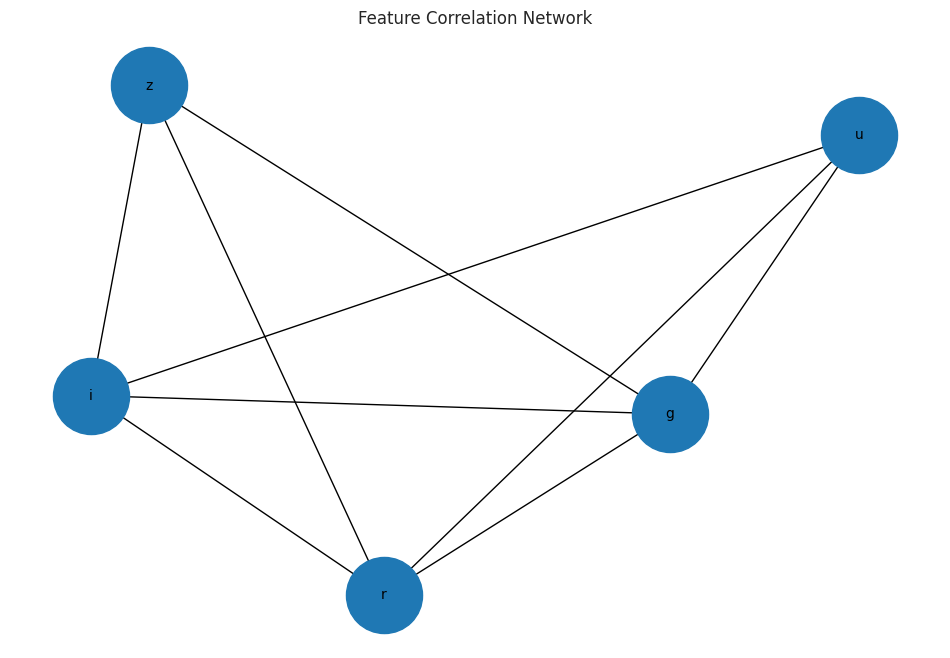

In [22]:
import networkx as nx

corr = train_df.corr(numeric_only=True)

G = nx.Graph()

threshold = 0.5

for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i, j]) > threshold:
            G.add_edge(i, j, weight=corr.loc[i, j])

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10
)

plt.title("Feature Correlation Network")
plt.axis('off')
plt.show()

## Feature engineering

In [23]:
def feature_eng(df_data):
    df_data['u_g'] = df_data['u'] - df_data['g']
    df_data['g_r'] = df_data['g'] - df_data['r']
    df_data['r_i'] = df_data['r'] - df_data['i']
    df_data['i_z'] = df_data['i'] - df_data['z']
    df_data['redshift_u_g'] = df_data['redshift'] * df_data['u_g']
    df_data['redshift_g_r'] = df_data['redshift'] * df_data['g_r']
    return df_data

train_df = feature_eng(train_df)
    

## Train test splitting

In [24]:
X = train_df.drop(['id', target_col], axis=1)
y = train_df[target_col]

print('Features shape:', X.shape)
print('Target shape:', y.shape)

# One-hot encoding categorical columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Features after encoding shape:", X.shape)

Features shape: (577347, 16)
Target shape: (577347,)
Features after encoding shape: (577347, 18)


In [25]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_valid.shape, y_valid.shape)

Training set shape: (461877, 18) (461877,)
Validation set shape: (115470, 18) (115470,)


In [26]:
le=LabelEncoder()
y_train_enc =le.fit_transform(y_train)
y_valid_enc = le.transform(y_valid)

## Model

In [27]:
num_classes = len(set(y_train_enc))

best_params = {
    "n_estimators": 813,
    "max_depth": 9,
    "learning_rate": 0.05877683053481154,
    "subsample": 0.9084850501281442,
    "colsample_bytree": 0.8812801254016399,
    "gamma": 0.16634613742497686,
    "min_child_weight": 8,

    "objective": "multi:softprob",
    "eval_metric": "mlogloss",
    "num_class": num_classes,

    "tree_method": "hist",
    "device": "cuda",
    "random_state": 42
}

xgb = XGBClassifier(**best_params)

xgb.fit(X_train, y_train_enc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8812801254016399, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.16634613742497686, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05877683053481154,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=8, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=813, n_jobs=None, num_class=3, ...)

Balanced Accuracy: 0.9556949911009283

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     75496
           1       0.97      0.96      0.96     23429
           2       0.93      0.92      0.93     16545

    accuracy                           0.97    115470
   macro avg       0.96      0.96      0.96    115470
weighted avg       0.97      0.97      0.97    115470



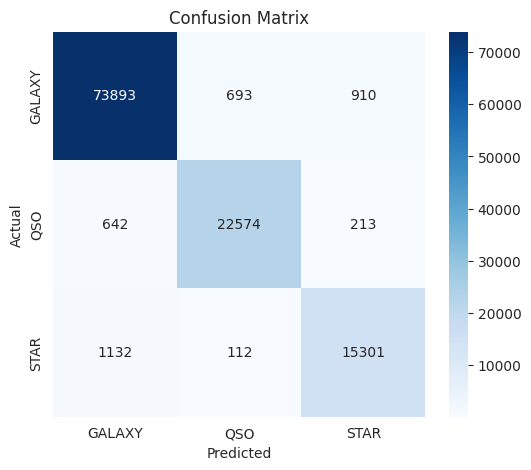

In [28]:
y_pred= xgb.predict(X_valid)
print("Balanced Accuracy:", balanced_accuracy_score(y_valid_enc, y_pred))
print("\nClassification Report:\n", classification_report(y_valid_enc, y_pred))

cm = confusion_matrix(y_valid_enc, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

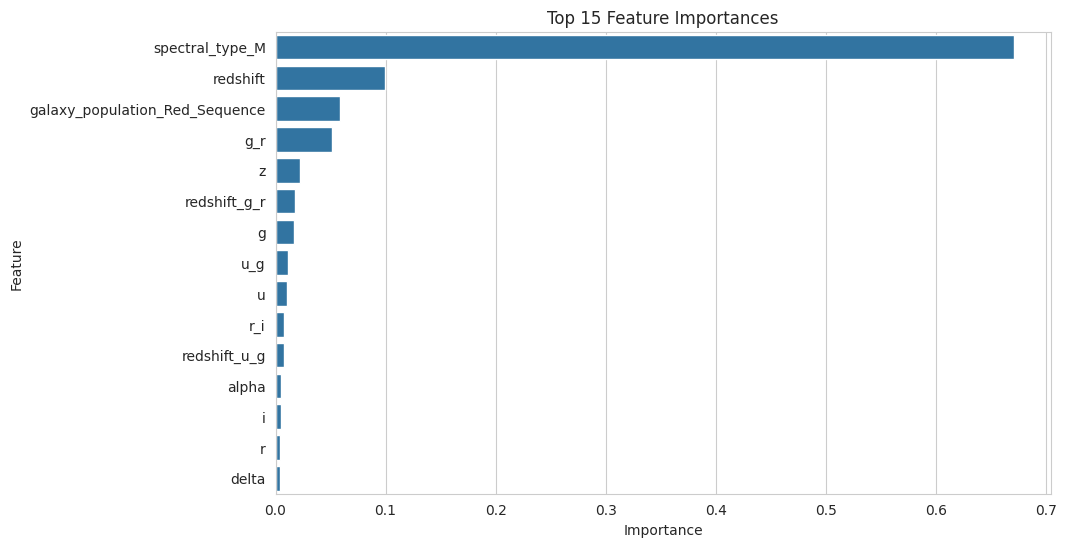

In [29]:
importances= xgb.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='Importance',y='Feature')
plt.title("Top 15 Feature Importances")
plt.show()

## Submission

In [30]:
test_df = feature_eng(test_df)
test_df_enc= pd.get_dummies(test_df)
test_df_enc = test_df_enc.reindex(columns=X.columns,fill_value=0)
test_pred = xgb.predict(test_df_enc)
test_pred_labels= le.inverse_transform(test_pred)
submission['class'] =test_pred_labels
submission.to_csv('submission.csv',index=False)
print("Submission file created!")

Submission file created!


In [31]:
submission.head()

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


## Thank you...pls upvote!!